# E-commerce Customer Analytics

**Analysing customer purchasing behaviour, revenue drivers and service quality for a Southeast-Asian online retailer**

| | |
|---|---|
| **Author** | Sak |
| **Tools** | Python 3, Pandas, NumPy, Matplotlib, Seaborn, SciPy |
| **Dataset** | `data/raw/ecommerce_orders_raw.csv` — 2,045 order records (synthetic, generated by `src/generate_dataset.py`) |
| **Period covered** | January 2024 – June 2025 |

---

## 1. Problem Definition & Project Scope

### 1.1 Business problem
An online retailer selling across seven Southeast-Asian markets has grown quickly but has never analysed its order history systematically. Management does not know **which products, customer groups and markets actually drive revenue**, **whether customers come back after their first purchase**, or **why some customers leave poor reviews and return products**. Marketing budget is spread evenly across channels and product categories, and decisions are made on intuition.

This project turns the raw order log into evidence-based answers to those questions so the business can focus its marketing, inventory and logistics efforts where they have the most impact.

### 1.2 Project scope

**In scope**

* Order-level transaction data from **1 January 2024 to 30 June 2025** (18 months).
* Customer attributes attached to each order: age, gender, country, city, sign-up date, segment and acquisition channel.
* Order attributes: product category, quantity, unit price, discount, shipping cost, payment method, device, delivery time, order status and review rating.
* Data cleaning (missing values, duplicates, validation), feature engineering, descriptive & statistical analysis, and visualisation with Pandas / Matplotlib / Seaborn.

**Out of scope**

* Product-level (SKU) analysis — the data is aggregated at category level.
* Cost of goods, profit margin, and marketing spend (not available in the dataset).
* Predictive / machine-learning modelling (e.g. churn prediction) — this project is descriptive and diagnostic only.
* Web-analytics events (page views, cart abandonment) — only completed orders are analysed.

---

## 2. Objectives & Analytical Questions

### 2.1 Measurable objectives

| # | Objective | Success measure |
|---|-----------|-----------------|
| **O1** | **Identify the main revenue drivers.** Quantify how revenue is distributed across product categories, customer segments, countries and acquisition channels. | Revenue share (%) per category / segment / country / channel, and identification of the groups that together produce ≥ 80 % of revenue. |
| **O2** | **Measure customer retention and value concentration.** Determine what proportion of customers are repeat buyers and how concentrated spending is among top customers. | Repeat-purchase rate (%), share of revenue from the top 20 % of customers, share of customers flagged as churn-risk. |
| **O3** | **Diagnose service-quality problems.** Test whether delivery speed and product returns are related to customer satisfaction (review rating). | Correlation coefficient between `delivery_days` and `review_rating`, mean rating by delivery-time band, return rate (%) per category. |

### 2.2 Analytical questions

| # | Question | Technique |
|---|----------|-----------|
| **Q1** | Which product categories generate the most revenue, and which have the highest return rates? | `groupby` + `agg`, sorting |
| **Q2** | How do customer segments (New / Regular / VIP) differ in order frequency, order value and total spend? | `groupby`, derived customer table |
| **Q3** | How do orders and revenue trend month by month — is there seasonality? | time-series `groupby`, line chart |
| **Q4** | Which countries and acquisition channels bring the most valuable customers? | `groupby`, `pivot_table` |
| **Q5** | Does delivery time affect the review rating customers give? | correlation, binning, box plot |
| **Q6** | What share of customers are repeat buyers, and how many are at risk of churning? | customer-level aggregation, RFM-style flags |
| **Q7** | Do device usage and payment preferences differ across age groups? | `crosstab` |

---
## 3. Dataset & Data Dictionary

The dataset was produced by `src/generate_dataset.py`, a reproducible generator (`seed = 42`) that simulates 2,000 orders from ~840 customers and then **deliberately injects realistic data-quality problems**: missing values, 45 exact duplicate rows, out-of-range numbers (negative ages, ratings above 5, discounts above 100 %, etc.) and inconsistent category spelling. The full data dictionary is also available in [`docs/data_dictionary.md`](../docs/data_dictionary.md).

| Field | Data type | Description | Example |
|---|---|---|---|
| `order_id` | string | Unique order identifier | `ORD100305` |
| `order_date` | date | Date the order was placed | `2024-04-25` |
| `customer_id` | string | Unique customer identifier (repeats across orders) | `C1122` |
| `age` | integer | Customer age in years at time of analysis | `36` |
| `gender` | category | Customer gender (`Female` / `Male`) | `Male` |
| `country` | category | Customer's country | `Cambodia` |
| `city` | category | Customer's city | `Phnom Penh` |
| `signup_date` | date | Date the customer created an account | `2024-03-21` |
| `customer_segment` | category | Loyalty tier: `New`, `Regular`, `VIP` | `VIP` |
| `acquisition_channel` | category | Marketing channel through which the customer was acquired | `Referral` |
| `product_category` | category | Product category of the order (7 categories) | `Beauty` |
| `quantity` | integer | Number of units ordered | `1` |
| `unit_price` | float | Price per unit in USD | `37.40` |
| `discount_pct` | float | Discount applied to the order (%) | `5.0` |
| `shipping_cost` | float | Shipping fee charged in USD (free above $120) | `9.99` |
| `payment_method` | category | Payment method used | `Credit Card` |
| `device_type` | category | Device used to place the order | `Desktop` |
| `delivery_days` | float | Days between order and delivery (blank if cancelled) | `7.0` |
| `order_status` | category | `Delivered`, `Cancelled` or `Returned` | `Returned` |
| `review_rating` | float | Customer rating 1–5 (blank if no review left) | `3.0` |

**Derived columns created in Section 8:** `gross_amount`, `discount_amount`, `total_amount`, `net_revenue`, `customer_tenure_days`, `age_group`, `order_value_tier`, `order_month`, `order_weekday`, `is_returned`, `has_review`.

---
## 4. Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# Make src/ importable whether the notebook is run from notebooks/ or the repo root
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
from data_cleaning import build_customer_table

# Display & style settings
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.2f}".format)

PALETTE = ["#2563eb", "#f59e0b", "#10b981", "#ef4444", "#8b5cf6", "#0ea5e9", "#f97316"]
sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.0)
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 13})

FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()

print("pandas", pd.__version__, "| numpy", np.__version__, "| project root:", ROOT)

pandas 3.0.2 | numpy 2.4.4 | project root: /home/claude/ecommerce-customer-analytics


---
## 5. Load & Explore the Dataset (Pandas)

We load the **raw** file (before any cleaning) so that every quality issue is visible.

In [2]:
df = pd.read_csv(ROOT / "data" / "raw" / "ecommerce_orders_raw.csv",
                 parse_dates=["order_date", "signup_date"])
df.head()

,order_id,order_date,customer_id,age,gender,country,city,signup_date,customer_segment,acquisition_channel,product_category,quantity,unit_price,discount_pct,shipping_cost,payment_method,device_type,delivery_days,order_status,review_rating
0,ORD100305,2024-04-25,C1122,36.00,Male,Cambodia,Phnom Penh,2024-03-21,VIP,Referral,Beauty,1,37.40,5.00,9.99,Credit Card,Desktop,7.00,Returned,3.00
1,ORD101283,2024-12-14,C1328,21.00,Male,Cambodia,Sihanoukville,2023-12-11,New,Organic Search,Home & Kitchen,2,74.12,0.00,0.00,E-Wallet,Desktop,4.00,Delivered,3.00
2,ORD100368,2024-05-11,C1045,36.00,Female,Indonesia,Surabaya,2023-04-22,Regular,Organic Search,Electronics,1,312.10,15.00,0.00,Cash on Delivery,Mobile,NaN,Cancelled,NaN
3,ORD100479,2024-06-08,C1187,21.00,Male,Cambodia,Battambang,2024-06-07,Regular,Paid Ads,Books,2,8.91,15.00,9.99,Bank Transfer,Mobile,8.00,Delivered,4.00
4,ORD101537,2025-02-19,C1302,44.00,Female,Thailand,Bangkok,2023-02-20,Regular,Referral,Fashion,1,96.68,15.00,2.99,Cash on Delivery,Mobile,7.00,Delivered,4.00


In [3]:
print("Shape (rows, columns):", df.shape)
print("\nColumns:", list(df.columns))

Shape (rows, columns): (2045, 20)

Columns: ['order_id', 'order_date', 'customer_id', 'age', 'gender', 'country', 'city', 'signup_date', 'customer_segment', 'acquisition_channel', 'product_category', 'quantity', 'unit_price', 'discount_pct', 'shipping_cost', 'payment_method', 'device_type', 'delivery_days', 'order_status', 'review_rating']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2045 entries, 0 to 2044
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             2045 non-null   str           
 1   order_date           2045 non-null   datetime64[us]
 2   customer_id          2045 non-null   str           
 3   age                  1984 non-null   float64       
 4   gender               2045 non-null   str           
 5   country              2045 non-null   str           
 6   city                 2015 non-null   str           
 7   signup_date          2045 non-null   datetime64[us]
 8   customer_segment     2045 non-null   str           
 9   acquisition_channel  2045 non-null   str           
 10  product_category     2045 non-null   str           
 11  quantity             2045 non-null   int64         
 12  unit_price           2025 non-null   float64       
 13  discount_pct         2045 non-null   float64

In [5]:
df.describe()

,order_date,age,signup_date,quantity,unit_price,discount_pct,shipping_cost,delivery_days,review_rating
count,2045,"1,984.00",2045,"2,045.00","2,025.00","2,045.00","2,045.00","1,907.00","1,264.00"
mean,2024-10-12 00:09:09.242053,34.60,2023-05-17 13:02:19.070904,1.78,81.01,8.34,3.99,5.96,3.55
min,2024-01-01 00:00:00,-5.00,2022-01-01 00:00:00,-2.00,-100.00,-10.00,0.00,-3.00,0.00
25%,2024-06-13 00:00:00,27.00,2022-10-02 00:00:00,1.00,25.21,0.00,0.00,3.00,3.00
50%,2024-10-20 00:00:00,34.00,2023-05-16 00:00:00,1.00,50.80,5.00,2.99,6.00,4.00
75%,2025-02-02 00:00:00,41.00,2023-12-26 00:00:00,2.00,101.24,15.00,6.99,9.00,4.00
max,2025-06-30 00:00:00,210.00,2024-09-26 00:00:00,5.00,548.58,150.00,9.99,60.00,7.00
std,NaN,11.48,NaN,1.05,87.25,9.88,3.63,3.49,0.91


In [6]:
# Categorical columns overview
df.describe(include="object")

,order_id,customer_id,gender,country,city,customer_segment,acquisition_channel,product_category,payment_method,device_type,order_status
count,2045,2045,2045,2045,2015,2045,2045,2045,2004,2045,2045
unique,2000,724,4,7,20,3,5,19,5,3,3
top,ORD100056,C1518,Female,Cambodia,Singapore,VIP,Organic Search,Electronics,Credit Card,Mobile,Delivered
freq,2,11,1073,637,213,838,604,478,659,1204,1693


**Interpretation.** The raw file contains **2,045 rows × 20 columns**. `df.info()` shows that most columns have the expected dtype, but several already reveal missing data (`age`, `city`, `unit_price`, `payment_method`, `delivery_days`, `review_rating`). `df.describe()` immediately flags impossible values: the minimum `age` is **−5** and the maximum **210**, `quantity` goes down to **−2**, `discount_pct` reaches **150 %**, `unit_price` has negative values, `delivery_days` ranges from **−3 to 60**, and `review_rating` spans **0 to 7** even though the valid scale is 1–5. The categorical summary shows `product_category` has **more than the 7 expected unique values** (inconsistent capitalisation / whitespace) and `gender` has 4 values instead of 2. All of these are dealt with in Sections 6–8.

---
## 6. Identify & Handle Missing Values

In [7]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
})
missing[missing.missing_count > 0].sort_values("missing_count", ascending=False)

,missing_count,missing_pct
review_rating,781,38.19
delivery_days,138,6.75
age,61,2.98
payment_method,41,2.00
city,30,1.47
unit_price,20,0.98


In [8]:
# Are review ratings missing at random, or only for certain statuses?
pd.crosstab(df["order_status"], df["review_rating"].isna(), normalize="index").round(3) \
  .rename(columns={False: "has_rating", True: "rating_missing"})

review_rating,has_rating,rating_missing
order_status,,
Cancelled,0.00,1.00
Delivered,0.65,0.35
Returned,0.73,0.27


**Interpretation & handling strategy.** Missing values fall into two very different groups:

1. **Structurally missing (not an error).** `delivery_days` is empty for *every* cancelled order (a cancelled order is never delivered), and `review_rating` is empty for all cancelled orders and for roughly a third of delivered / returned orders (customers simply did not leave a review). These blanks carry information, so **they are kept as `NaN`** rather than invented. Analyses on rating use only the rows that have a rating.
2. **Genuinely missing attributes (data-entry / export errors).** `age` (~3 %), `payment_method` (~2 %), `city` (~1.5 %) and `unit_price` (~1 %) are missing at random in small proportions. The handling rule per column is:

| Column | Method | Rationale |
|---|---|---|
| `age` | **Median imputation** | Numeric and contains outliers (see Section 8); the median is robust to those outliers, unlike the mean. |
| `payment_method` | **Mode imputation** | Categorical; the most frequent method is the most likely value. Only 2 % of rows are affected so bias is negligible. |
| `city` | **Mode within country** | City depends on country, so imputing the most common city *of the same country* is more accurate than a global mode. |
| `unit_price` | **Row removal** | Price is required to compute revenue; imputing it would fabricate revenue figures. Only ~1 % of rows are affected. |

Imputation is applied **after** de-duplication and validation (Sections 7–8) so that duplicates and invalid values do not distort the medians / modes used for filling.

---
## 7. Identify & Handle Duplicate Records

In [9]:
# First standardise text so that "electronics" and " Electronics " are recognised as the same value
df["product_category"] = df["product_category"].str.strip().str.title()
df["gender"] = df["gender"].replace({"F": "Female", "M": "Male"})
print("Unique categories:", sorted(df["product_category"].unique()))
print("Unique genders   :", sorted(df["gender"].unique()))

Unique categories: ['Beauty', 'Books', 'Electronics', 'Fashion', 'Home & Kitchen', 'Sports', 'Toys']
Unique genders   : ['Female', 'Male']


In [10]:
n_before = len(df)
n_dup_exact = df.duplicated().sum()
n_dup_id = df.duplicated(subset="order_id").sum()
print(f"Exact duplicate rows            : {n_dup_exact}")
print(f"Duplicate order_id values       : {n_dup_id}")

# Show a few examples
df[df.duplicated(keep=False)].sort_values("order_id").head(6)

Exact duplicate rows            : 45
Duplicate order_id values       : 45


,order_id,order_date,customer_id,age,gender,country,city,signup_date,customer_segment,acquisition_channel,product_category,quantity,unit_price,discount_pct,shipping_cost,payment_method,device_type,delivery_days,order_status,review_rating
1614,ORD100029,2024-01-14,C1492,31.00,Female,Thailand,Phuket,2024-01-02,New,Referral,Electronics,1,212.09,0.00,0.00,Bank Transfer,Tablet,1.00,Delivered,NaN
44,ORD100029,2024-01-14,C1492,31.00,Female,Thailand,Phuket,2024-01-02,New,Referral,Electronics,1,212.09,0.00,0.00,Bank Transfer,Tablet,1.00,Delivered,NaN
20,ORD100056,2024-01-23,C1457,25.00,Female,Vietnam,Da Nang,2022-06-26,Regular,Organic Search,Books,3,16.33,0.00,4.99,Bank Transfer,Mobile,NaN,Cancelled,NaN
293,ORD100056,2024-01-23,C1457,25.00,Female,Vietnam,Da Nang,2022-06-26,Regular,Organic Search,Books,3,16.33,0.00,4.99,Bank Transfer,Mobile,NaN,Cancelled,NaN
66,ORD100065,2024-01-26,C1566,32.00,Male,Malaysia,Kuala Lumpur,2023-01-29,VIP,Organic Search,Fashion,1,76.43,15.00,6.99,Credit Card,Desktop,2.00,Delivered,5.00
1061,ORD100065,2024-01-26,C1566,32.00,Male,Malaysia,Kuala Lumpur,2023-01-29,VIP,Organic Search,Fashion,1,76.43,15.00,6.99,Credit Card,Desktop,2.00,Delivered,5.00


In [11]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"Rows before: {n_before:,}  |  duplicates removed: {n_dup_exact}  |  rows remaining: {len(df):,}")
assert df["order_id"].is_unique, "order_id should now be unique"

Rows before: 2,045  |  duplicates removed: 45  |  rows remaining: 2,000


**Interpretation.** After standardising text, **45 exact duplicate rows** were found, and each duplicated `order_id` matched an exact duplicate row — i.e. these are pure double-exports rather than legitimately repeated orders. They were removed with `drop_duplicates()`, leaving **2,000 unique orders**. Had we not standardised the text first, some duplicates whose category differed only in capitalisation would have escaped detection.

---
## 8. Data Validation

We check data types, category domains and numeric value ranges against explicit business rules.

In [12]:
RULES = {                      # column: (min allowed, max allowed)
    "age":           (18, 100),
    "quantity":      (1, 50),
    "unit_price":    (0.01, 5000),
    "discount_pct":  (0, 100),
    "shipping_cost": (0, 100),
    "delivery_days": (0, 30),
    "review_rating": (1, 5),
}
VALID_CATEGORIES = ["Electronics", "Fashion", "Home & Kitchen", "Beauty", "Sports", "Books", "Toys"]
VALID_STATUS     = ["Delivered", "Cancelled", "Returned"]

# --- 8.1 data types -------------------------------------------------------
print(df.dtypes, "\n")

# --- 8.2 categorical domains ---------------------------------------------
print("Invalid product_category :", (~df["product_category"].isin(VALID_CATEGORIES)).sum())
print("Invalid order_status     :", (~df["order_status"].isin(VALID_STATUS)).sum())
print("Invalid gender           :", (~df["gender"].isin(["Female", "Male"])).sum())

# --- 8.3 numeric ranges ---------------------------------------------------
report = []
for col, (lo, hi) in RULES.items():
    bad = df[col].notna() & ((df[col] < lo) | (df[col] > hi))
    report.append({"column": col, "min_allowed": lo, "max_allowed": hi,
                   "observed_min": df[col].min(), "observed_max": df[col].max(),
                   "invalid_rows": int(bad.sum())})
validation_report = pd.DataFrame(report)
validation_report

order_id                          str
order_date             datetime64[us]
customer_id                       str
age                           float64
gender                            str
country                           str
city                              str
signup_date            datetime64[us]
customer_segment                  str
acquisition_channel               str
product_category                  str
quantity                        int64
unit_price                    float64
discount_pct                  float64
shipping_cost                 float64
payment_method                    str
device_type                       str
delivery_days                 float64
order_status                      str
review_rating                 float64
dtype: object 

Invalid product_category : 0
Invalid order_status     : 0
Invalid gender           : 0


,column,min_allowed,max_allowed,observed_min,observed_max,invalid_rows
0,age,18.00,100,-5.00,210.00,6
1,quantity,1.00,50,-2.00,5.00,5
2,unit_price,0.01,5000,-100.00,548.58,3
3,discount_pct,0.00,100,-10.00,150.00,4
4,shipping_cost,0.00,100,0.00,9.99,0
5,delivery_days,0.00,30,-3.00,60.00,3
6,review_rating,1.00,5,0.00,7.00,4


In [13]:
# --- 8.4 logical rule: an order cannot be placed before the customer signed up
print("Orders placed before sign-up:", (df["order_date"] < df["signup_date"]).sum())

# Examples of the invalid rows
df.loc[(df["age"] < 18) | (df["age"] > 100) | (df["quantity"] < 1) | (df["review_rating"] > 5),
       ["order_id", "age", "quantity", "unit_price", "discount_pct", "review_rating"]].head(10)

Orders placed before sign-up: 0


,order_id,age,quantity,unit_price,discount_pct,review_rating
121,ORD101976,34.00,1,45.74,5.00,7.00
428,ORD100365,38.00,1,75.97,0.00,6.00
468,ORD100292,210.00,1,65.80,5.00,3.00
525,ORD100182,34.00,0,30.53,10.00,NaN
551,ORD101914,-5.00,5,31.54,0.00,4.00
1225,ORD100958,42.00,-2,52.84,10.00,3.00
1354,ORD101581,37.00,0,42.43,10.00,NaN
1388,ORD100604,0.00,2,58.69,5.00,NaN
1402,ORD101191,18.00,0,40.39,0.00,NaN
1612,ORD101749,130.00,1,21.95,20.00,NaN


In [14]:
# --- 8.5 Fix: invalid values are impossible, so treat them as missing ...
for col, (lo, hi) in RULES.items():
    bad = df[col].notna() & ((df[col] < lo) | (df[col] > hi))
    df.loc[bad, col] = np.nan

# ... then drop rows whose transaction-critical fields (quantity / price) are unusable
critical = df["quantity"].isna() | df["unit_price"].isna()
print(f"Rows dropped (missing/invalid quantity or unit_price): {critical.sum()}")
df = df[~critical].reset_index(drop=True)

# --- 8.6 Impute the remaining missing attributes (strategy from Section 6)
df["age"] = df["age"].fillna(df["age"].median())
df["payment_method"] = df["payment_method"].fillna(df["payment_method"].mode()[0])
df["city"] = df.groupby("country")["city"].transform(lambda s: s.fillna(s.mode()[0]))
df["discount_pct"] = df["discount_pct"].fillna(0)                      # invalid discount -> no discount
not_cancelled = df["order_status"] != "Cancelled"
df.loc[not_cancelled, "delivery_days"] = df.loc[not_cancelled, "delivery_days"] \
                                           .fillna(df.loc[not_cancelled, "delivery_days"].median())

# Convert to appropriate types
df["age"] = df["age"].astype(int)
df["quantity"] = df["quantity"].astype(int)
for c in ["gender", "country", "customer_segment", "acquisition_channel",
          "product_category", "payment_method", "device_type", "order_status"]:
    df[c] = df[c].astype("category")

print(f"\nClean dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.isnull().sum()[lambda s: s > 0]

Rows dropped (missing/invalid quantity or unit_price): 28



Clean dataset: 1,972 rows x 20 columns


delivery_days    131
review_rating    749
dtype: int64

**Interpretation.** Validation found **25 out-of-range values** across seven numeric fields (6 impossible ages, 5 non-positive quantities, 3 negative prices, 4 discounts outside 0–100 %, 3 implausible delivery times and 4 ratings outside 1–5) plus no domain violations after text standardisation and no orders dated before sign-up. Because these values are physically impossible, they were treated as missing. **28 rows** (invalid or missing `quantity` / `unit_price`) were dropped because revenue cannot be computed without them; the remaining gaps were imputed as planned. The clean dataset has **1,972 orders**, and the only remaining `NaN`s are the *structural* ones — `delivery_days` for cancelled orders and `review_rating` where no review was left. Categorical columns were converted to the `category` dtype and `age` / `quantity` back to integers.

---
## 9. Derived / Calculated Columns

In [15]:
# --- Monetary fields ------------------------------------------------------
df["gross_amount"]    = (df["quantity"] * df["unit_price"]).round(2)
df["discount_amount"] = (df["gross_amount"] * df["discount_pct"] / 100).round(2)
df["total_amount"]    = (df["gross_amount"] - df["discount_amount"] + df["shipping_cost"]).round(2)
# Net revenue: cancelled and returned orders are refunded, so they contribute 0
df["net_revenue"]     = np.where(df["order_status"] == "Delivered", df["total_amount"], 0.0)

# --- Customer & time fields ----------------------------------------------
df["customer_tenure_days"] = (df["order_date"] - df["signup_date"]).dt.days
df["age_group"] = pd.cut(df["age"], bins=[17, 24, 34, 44, 54, 100],
                         labels=["18-24", "25-34", "35-44", "45-54", "55+"])
df["order_value_tier"] = pd.cut(df["total_amount"], bins=[-np.inf, 50, 150, 400, np.inf],
                                labels=["Low (<$50)", "Medium ($50-150)", "High ($150-400)", "Premium (>$400)"])
df["order_month"]   = df["order_date"].dt.to_period("M").astype(str)
df["order_weekday"] = df["order_date"].dt.day_name()

# --- Flags ----------------------------------------------------------------
df["is_returned"] = (df["order_status"] == "Returned").astype(int)
df["has_review"]  = df["review_rating"].notna().astype(int)

df[["order_id", "quantity", "unit_price", "discount_pct", "shipping_cost",
    "gross_amount", "discount_amount", "total_amount", "net_revenue",
    "customer_tenure_days", "age_group", "order_value_tier"]].head(8)

,order_id,quantity,unit_price,discount_pct,shipping_cost,gross_amount,discount_amount,total_amount,net_revenue,customer_tenure_days,age_group,order_value_tier
0,ORD100305,1,37.40,5.00,9.99,37.40,1.87,45.52,0.00,35,35-44,Low (<$50)
1,ORD101283,2,74.12,0.00,0.00,148.24,0.00,148.24,148.24,369,18-24,Medium ($50-150)
2,ORD100368,1,312.10,15.00,0.00,312.10,46.82,265.28,0.00,385,35-44,High ($150-400)
3,ORD100479,2,8.91,15.00,9.99,17.82,2.67,25.14,25.14,1,18-24,Low (<$50)
4,ORD101537,1,96.68,15.00,2.99,96.68,14.50,85.17,85.17,730,35-44,Medium ($50-150)
5,ORD101674,1,103.25,10.00,2.99,103.25,10.32,95.92,0.00,720,18-24,Medium ($50-150)
6,ORD100519,1,134.52,15.00,0.00,134.52,20.18,114.34,114.34,597,35-44,Medium ($50-150)
7,ORD101982,4,47.68,0.00,0.00,190.72,0.00,190.72,190.72,616,35-44,High ($150-400)


In [16]:
# Save the clean, enriched dataset for reuse
CLEAN_PATH = ROOT / "data" / "processed" / "ecommerce_orders_clean.csv"
df.to_csv(CLEAN_PATH, index=False)
print("Saved ->", CLEAN_PATH.relative_to(ROOT), df.shape)

Saved -> data/processed/ecommerce_orders_clean.csv (1972, 31)


**Interpretation.** Eleven new columns were derived. The most important are `total_amount` (what the customer paid: quantity × price − discount + shipping) and `net_revenue` (revenue the business actually keeps, which is zero for cancelled and returned orders). `age_group` and `order_value_tier` turn continuous variables into bands that make grouping and cross-tabulation readable, while `customer_tenure_days` measures how long a customer had been registered when they placed each order.

---
## 10. Data Analysis with Pandas

Each sub-section answers one of the analytical questions using filtering, sorting, grouping, aggregation, pivot tables and crosstabs.

### 10.1 Overview KPIs

In [17]:
delivered = df[df["order_status"] == "Delivered"]           # filtering
kpis = pd.Series({
    "Total orders":              len(df),
    "Unique customers":          df["customer_id"].nunique(),
    "Delivered orders":          len(delivered),
    "Net revenue (USD)":         df["net_revenue"].sum(),
    "Average order value (USD)": df["total_amount"].mean(),
    "Median order value (USD)":  df["total_amount"].median(),
    "Return rate":               df["is_returned"].mean(),
    "Cancellation rate":         (df["order_status"] == "Cancelled").mean(),
    "Average review rating":     df["review_rating"].mean(),
    "Review response rate":      df["has_review"].mean(),
})
kpis.to_frame("value")

,value
Total orders,"1,972.00"
Unique customers,721.00
Delivered orders,"1,629.00"
Net revenue (USD),"227,154.59"
Average order value (USD),136.47
Median order value (USD),75.73
Return rate,0.11
Cancellation rate,0.07
Average review rating,3.55
Review response rate,0.62


**Interpretation.** Over 18 months the retailer processed **1,972 valid orders from 721 customers**, earning **≈ $227 k** in net revenue. The average order is worth **$136** but the median is only **$76**, a sign that a minority of large (mostly Electronics) orders pull the mean up. Roughly **1 in 9 orders is returned (10.8 %)** and **6.6 % are cancelled**, so about 17 % of orders generate no revenue at all — a leakage worth investigating. Customers leave a review on 62 % of orders, with an average rating of **3.55 / 5**.

### 10.2 Q1 — Revenue and return rate by product category

In [18]:
cat = (df.groupby("product_category", observed=True)
         .agg(orders=("order_id", "count"),
              net_revenue=("net_revenue", "sum"),
              avg_order_value=("total_amount", "mean"),
              return_rate=("is_returned", "mean"),
              avg_rating=("review_rating", "mean"))
         .sort_values("net_revenue", ascending=False))
cat["revenue_share"] = cat["net_revenue"] / cat["net_revenue"].sum()
cat["cum_revenue_share"] = cat["revenue_share"].cumsum()
cat

,orders,net_revenue,avg_order_value,return_rate,avg_rating,revenue_share,cum_revenue_share
product_category,,,,,,,
Electronics,466,"122,244.92",303.56,0.10,3.60,0.54,0.54
Home & Kitchen,332,"32,602.84",121.05,0.11,3.59,0.14,0.68
Fashion,397,"27,945.95",88.92,0.14,3.54,0.12,0.80
Sports,203,"18,471.29",110.59,0.12,3.52,0.08,0.89
Beauty,262,"12,467.50",56.59,0.11,3.38,0.05,0.94
Toys,144,"8,604.97",63.07,0.06,3.67,0.04,0.98
Books,168,"4,817.12",34.58,0.08,3.50,0.02,1.00


In [19]:
# Highest return rates (sorting on a different key)
cat.sort_values("return_rate", ascending=False)[["orders", "return_rate", "avg_rating"]]

,orders,return_rate,avg_rating
product_category,,,
Fashion,397,0.14,3.54
Sports,203,0.12,3.52
Beauty,262,0.11,3.38
Home & Kitchen,332,0.11,3.59
Electronics,466,0.10,3.60
Books,168,0.08,3.50
Toys,144,0.06,3.67


**Interpretation (Q1).** Revenue is heavily concentrated: **Electronics alone produces 54 % of net revenue** from only 24 % of orders, because its average order value ($304) is 2.5–9× that of other categories. Electronics, Home & Kitchen and Fashion together deliver **≈ 80 % of revenue** (objective O1). Books and Toys are high-volume, low-value categories contributing under 6 % combined. Returns tell a different story: **Fashion has the highest return rate (13.6 %)**, followed by Sports (12.3 %); Toys (6.2 %) and Books (8.3 %) are returned least. Fashion's combination of moderate revenue and the highest return rate makes it the priority for sizing / product-description improvements.

### 10.3 Q2 — Customer segments

In [20]:
seg = (df.groupby("customer_segment", observed=True)
         .agg(customers=("customer_id", "nunique"),
              orders=("order_id", "count"),
              net_revenue=("net_revenue", "sum"),
              avg_order_value=("total_amount", "mean"),
              avg_discount_pct=("discount_pct", "mean"),
              return_rate=("is_returned", "mean")))
seg["orders_per_customer"] = seg["orders"] / seg["customers"]
seg["revenue_per_customer"] = seg["net_revenue"] / seg["customers"]
seg["revenue_share"] = seg["net_revenue"] / seg["net_revenue"].sum()
seg.sort_values("revenue_per_customer", ascending=False)

,customers,orders,net_revenue,avg_order_value,avg_discount_pct,return_rate,orders_per_customer,revenue_per_customer,revenue_share
customer_segment,,,,,,,,,
VIP,167,807,"90,017.04",131.61,9.24,0.10,4.83,539.02,0.40
Regular,325,795,"94,704.85",141.04,7.29,0.12,2.45,291.40,0.42
New,229,370,"42,432.70",137.24,8.01,0.09,1.62,185.30,0.19


**Interpretation (Q2).** **VIP customers are 23 % of the customer base but generate 40 % of revenue.** They place 4.8 orders each on average versus 2.4 for Regular and 1.6 for New customers, and each VIP is worth **≈ $540** in net revenue — about 1.9× a Regular customer and 2.9× a New customer. Average order value is similar across segments, so the difference comes almost entirely from **purchase frequency**, not basket size. VIPs also receive the largest average discounts (≈ 9 % vs 7–8 % for other segments), which is worth monitoring so that loyalty pricing does not erode margin.

### 10.4 Q3 — Monthly trend

In [21]:
monthly = (df.groupby("order_month")
             .agg(orders=("order_id", "count"),
                  net_revenue=("net_revenue", "sum"),
                  customers=("customer_id", "nunique")))
monthly["revenue_mom_change_pct"] = monthly["net_revenue"].pct_change().mul(100).round(1)
monthly

,orders,net_revenue,customers,revenue_mom_change_pct
order_month,,,,
2024-01,75,"7,359.87",70,NaN
2024-02,66,"6,957.91",62,-5.50
2024-03,75,"8,068.67",68,16.00
2024-04,101,"13,645.22",92,69.10
2024-05,125,"13,575.65",111,-0.50
2024-06,113,"15,271.40",104,12.50
2024-07,110,"12,101.71",96,-20.80
2024-08,137,"12,444.07",119,2.80
2024-09,119,"16,057.95",106,29.00


In [22]:
# Pivot: revenue by month and category (rows = month, columns = category)
pivot_month_cat = pd.pivot_table(df, values="net_revenue", index="order_month",
                                 columns="product_category", aggfunc="sum", observed=True).round(0)
pivot_month_cat.tail(8)

product_category,Beauty,Books,Electronics,Fashion,Home & Kitchen,Sports,Toys
order_month,,,,,,,
2024-11,"1,315.00",380.00,"10,831.00","2,182.00","2,550.00","1,152.00",445.00
2024-12,"1,862.00",483.00,"19,356.00","1,982.00","3,113.00","1,073.00",356.00
2025-01,560.00,158.00,"4,663.00","2,021.00","1,539.00","1,120.00",440.00
2025-02,566.00,190.00,"4,915.00","1,129.00","1,096.00",236.00,177.00
2025-03,522.00,154.00,"5,152.00","1,333.00","2,540.00",695.00,651.00
2025-04,840.00,121.00,"1,931.00","1,791.00","1,879.00","1,368.00",333.00
2025-05,721.00,270.00,"5,981.00","1,458.00","1,778.00","1,865.00",298.00
2025-06,766.00,111.00,"3,966.00","2,446.00","1,818.00",944.00,368.00


**Interpretation (Q3).** Orders grew steadily through 2024 and show a **clear year-end peak: December 2024 produced 183 orders and $28.2 k in revenue — about 2.4× the monthly average of the first quarter.** November was the second-strongest month. After the holiday season, volume drops sharply in January–February (revenue −63 % month-on-month in January), then recovers from March. The first half of 2025 tracks slightly above the same months of 2024 (e.g. June 2025: 123 orders vs 113 in June 2024), indicating modest underlying growth on top of strong seasonality. The month × category pivot shows the December spike is driven mainly by Electronics.

### 10.5 Q4 — Countries and acquisition channels

In [23]:
country = (df.groupby("country", observed=True)
             .agg(customers=("customer_id", "nunique"),
                  orders=("order_id", "count"),
                  net_revenue=("net_revenue", "sum"),
                  avg_order_value=("total_amount", "mean"))
             .sort_values("net_revenue", ascending=False))
country["revenue_per_customer"] = country["net_revenue"] / country["customers"]
country["revenue_share"] = country["net_revenue"] / country["net_revenue"].sum()
country

,customers,orders,net_revenue,avg_order_value,revenue_per_customer,revenue_share
country,,,,,,
Cambodia,231,616,"78,455.13",148.39,339.63,0.35
Thailand,124,361,"44,489.72",142.20,358.79,0.20
Vietnam,133,389,"37,344.47",118.90,280.79,0.16
Singapore,78,209,"23,714.24",133.01,304.03,0.10
Malaysia,66,170,"17,142.51",119.24,259.73,0.08
Philippines,52,141,"14,095.45",132.77,271.07,0.06
Indonesia,37,86,"11,913.07",155.01,321.97,0.05


In [24]:
channel = (df.groupby("acquisition_channel", observed=True)
             .agg(customers=("customer_id", "nunique"),
                  orders=("order_id", "count"),
                  net_revenue=("net_revenue", "sum"))
             .assign(revenue_per_customer=lambda x: x["net_revenue"] / x["customers"],
                     orders_per_customer=lambda x: x["orders"] / x["customers"])
             .sort_values("revenue_per_customer", ascending=False))
channel

,customers,orders,net_revenue,revenue_per_customer,orders_per_customer
acquisition_channel,,,,,
Social Media,198,540,"65,929.28",332.98,2.73
Email,110,319,"35,737.12",324.88,2.90
Paid Ads,134,365,"43,208.11",322.45,2.72
Organic Search,210,584,"65,956.36",314.08,2.78
Referral,69,164,"16,323.72",236.58,2.38


In [25]:
# Pivot: average order value by country x segment
pd.pivot_table(df, values="total_amount", index="country", columns="customer_segment",
               aggfunc="mean", margins=True, margins_name="All", observed=True).round(1)

customer_segment,New,Regular,VIP,All
country,,,,
Cambodia,141.00,148.90,151.10,148.40
Indonesia,155.10,184.00,125.00,155.00
Malaysia,113.10,138.30,100.10,119.20
Philippines,123.70,164.30,116.10,132.80
Singapore,150.10,122.30,131.60,133.00
Thailand,141.50,147.30,138.20,142.20
Vietnam,119.40,122.20,115.00,118.90
All,137.20,141.00,131.60,136.50


**Interpretation (Q4).** **Cambodia is the core market: 32 % of customers and 35 % of revenue**, with the second-highest revenue per customer ($340). Thailand and Vietnam follow, together adding another 36 % of revenue. Indonesia is the smallest market but has the highest average order value ($155), suggesting untapped potential. Across channels, **Social Media and Organic Search each bring ~200 customers and ~$66 k**, while Email-acquired customers are the most valuable per head ($325) despite being fewer. **Referral customers are the least valuable (≈ $237 per customer, 29 % below the average)** — the referral programme is bringing in low-spending customers.

### 10.6 Q5 — Delivery time vs. review rating

In [26]:
rated = df.dropna(subset=["review_rating", "delivery_days"]).copy()   # filtering
rated["delivery_band"] = pd.cut(rated["delivery_days"], bins=[0, 3, 6, 9, 30],
                                labels=["1-3 days", "4-6 days", "7-9 days", "10+ days"])
by_band = rated.groupby("delivery_band", observed=True)["review_rating"] \
               .agg(["count", "mean", "median", "std"]).round(2)
by_band

,count,mean,median,std
delivery_band,,,,
1-3 days,338,3.96,4.00,0.87
4-6 days,356,3.65,4.00,0.82
7-9 days,318,3.34,3.00,0.80
10+ days,211,3.02,3.00,0.83


In [27]:
# Rating by order status and share of low ratings (1-2 stars)
rated["low_rating"] = rated["review_rating"] <= 2
rated.groupby("order_status", observed=True).agg(reviews=("review_rating", "count"),
                                                  avg_rating=("review_rating", "mean"),
                                                  low_rating_share=("low_rating", "mean")).round(3)

,reviews,avg_rating,low_rating_share
order_status,,,
Delivered,1068,3.69,0.07
Returned,155,2.57,0.45


**Interpretation (Q5).** Delivery speed has a strong, monotonic effect on satisfaction: orders delivered within **1–3 days average 3.96 stars**, falling to **3.65** (4–6 days), **3.34** (7–9 days) and **3.02** for deliveries taking 10 days or more — almost a full star lower. Returned orders are rated far worse (2.57) than delivered ones (3.69), and nearly half of returned-order reviews are 1–2 stars. Section 11 confirms the delivery/rating relationship is statistically significant (objective O3).

### 10.7 Q6 — Repeat purchase & churn risk (customer-level table)

In [28]:
cust = build_customer_table(df)      # one row per customer (see src/data_cleaning.py)
print("Customers:", len(cust))
cust.head()

Customers: 721


,customer_id,first_order,last_order,total_orders,total_spent,avg_order_value,returns,avg_rating,segment,country,channel,age,gender,recency_days,return_rate,is_repeat,churn_risk
0,C1000,2024-06-13,2025-05-15,3,568.37,189.46,0,3.50,Regular,Indonesia,Social Media,37,Male,47,0.00,1,Low
1,C1001,2024-12-29,2024-12-29,1,165.86,165.86,0,3.00,Regular,Philippines,Social Media,23,Female,184,0.00,0,High
2,C1002,2024-05-08,2024-12-27,4,428.54,197.20,2,3.00,Regular,Thailand,Email,42,Male,186,0.50,1,High
3,C1003,2024-06-14,2025-06-16,4,442.29,121.15,1,3.00,Regular,Malaysia,Email,44,Male,15,0.25,1,Low
4,C1004,2024-01-23,2025-05-01,5,347.65,69.53,0,4.67,Regular,Thailand,Referral,18,Female,61,0.00,1,Low


In [29]:
repeat_rate = cust["is_repeat"].mean()
top20 = cust.sort_values("total_spent", ascending=False).head(int(len(cust) * 0.2))
top20_share = top20["total_spent"].sum() / cust["total_spent"].sum()

print(f"Repeat-purchase rate            : {repeat_rate:.1%}")
print(f"Revenue from top 20% customers  : {top20_share:.1%}")
print("\nChurn-risk distribution (no order in >180 days = High, 91-180 = Medium):")
print(cust["churn_risk"].value_counts(normalize=True).round(3))

cust.groupby("segment").agg(customers=("customer_id", "count"),
                            repeat_rate=("is_repeat", "mean"),
                            avg_orders=("total_orders", "mean"),
                            avg_total_spent=("total_spent", "mean"),
                            avg_recency_days=("recency_days", "mean")).round(2)

Repeat-purchase rate            : 67.1%
Revenue from top 20% customers  : 57.1%

Churn-risk distribution (no order in >180 days = High, 91-180 = Medium):
churn_risk
High     0.45
Low      0.34
Medium   0.20
Name: proportion, dtype: float64


,customers,repeat_rate,avg_orders,avg_total_spent,avg_recency_days
segment,,,,,
New,229,0.40,1.62,185.30,231.92
Regular,325,0.71,2.45,291.40,172.79
VIP,167,0.96,4.83,539.02,103.12


In [30]:
# Top 10 customers by lifetime spend (sorting)
cust.sort_values("total_spent", ascending=False) \
    [["customer_id", "segment", "country", "total_orders", "total_spent", "avg_rating", "recency_days", "churn_risk"]].head(10)

,customer_id,segment,country,total_orders,total_spent,avg_rating,recency_days,churn_risk
443,C1518,VIP,Thailand,11,"2,738.17",3.62,18,Low
266,C1310,VIP,Cambodia,9,"2,101.71",3.14,11,Low
586,C1684,Regular,Cambodia,3,"1,930.83",3.00,252,High
562,C1650,VIP,Thailand,9,"1,811.00",4.33,54,Low
350,C1404,VIP,Cambodia,3,"1,794.37",3.00,93,Medium
528,C1609,Regular,Cambodia,5,"1,735.36",3.00,153,Medium
179,C1210,VIP,Thailand,8,"1,717.29",3.33,15,Low
532,C1614,VIP,Cambodia,9,"1,554.52",3.75,60,Low
181,C1212,Regular,Cambodia,5,"1,552.52",3.67,65,Low
163,C1189,Regular,Cambodia,4,"1,497.87",3.00,188,High


**Interpretation (Q6).** **67 % of customers have ordered more than once**, which is healthy for e-commerce, and the **top 20 % of customers account for 57 % of revenue** (objective O2). Retention differs sharply by segment: 96 % of VIPs are repeat buyers versus only 40 % of New customers. The concern is recency — **45 % of customers have not ordered in more than 180 days** and are flagged as high churn risk, with New customers the most inactive (average recency ≈ 300 days). Win-back campaigns should target this group, while VIPs (recency ≈ 100 days) mainly need protection from lapsing.

### 10.8 Q7 — Device and payment preferences by age group (crosstabs)

In [31]:
ct_device = pd.crosstab(df["age_group"], df["device_type"], normalize="index").round(3)
ct_device

device_type,Desktop,Mobile,Tablet
age_group,,,
18-24,0.32,0.61,0.07
25-34,0.34,0.56,0.10
35-44,0.34,0.58,0.08
45-54,0.27,0.64,0.09
55+,0.31,0.60,0.10


In [32]:
ct_pay = pd.crosstab(df["age_group"], df["payment_method"], normalize="index").round(3)
ct_pay

payment_method,Bank Transfer,Cash on Delivery,Credit Card,E-Wallet,PayPal
age_group,,,,,
18-24,0.15,0.17,0.33,0.30,0.04
25-34,0.14,0.18,0.35,0.29,0.05
35-44,0.17,0.15,0.34,0.29,0.05
45-54,0.18,0.15,0.38,0.25,0.04
55+,0.23,0.08,0.27,0.39,0.04


In [33]:
# Raw counts with totals
pd.crosstab(df["age_group"], df["payment_method"], margins=True)

payment_method,Bank Transfer,Cash on Delivery,Credit Card,E-Wallet,PayPal,All
age_group,,,,,,
18-24,56,62,121,109,15,363
25-34,89,117,230,189,36,661
35-44,112,97,225,194,35,663
45-54,41,35,88,59,10,233
55+,12,4,14,20,2,52
All,310,315,678,571,98,1972


**Interpretation (Q7).** Mobile dominates every age band (56–64 % of orders), with desktop a distant second; there is no evidence that older customers avoid mobile — the 45–54 group is actually the *most* mobile (64 %). Payment behaviour is more age-dependent: Credit Card and E-Wallet are the two leading methods for customers under 55, but the **55+ group prefers E-Wallet (38 %) and Bank Transfer (23 %) and almost never uses Cash on Delivery (8 % vs 15–18 % elsewhere)**. Cash on Delivery is most popular among the youngest customers (17 %). A mobile-first checkout that keeps E-Wallet and card options prominent serves all age groups well.

---
## 11. Statistical Analysis

In [34]:
num_cols = ["total_amount", "unit_price", "quantity", "discount_pct", "delivery_days", "review_rating", "age"]
desc = df[num_cols].agg(["mean", "median", "min", "max", "std", "var"]).T
desc["mode"] = [df[c].mode().iloc[0] for c in num_cols]
desc["skewness"] = df[num_cols].skew()
desc = desc[["mean", "median", "mode", "min", "max", "std", "var", "skewness"]]
desc

,mean,median,mode,min,max,std,var,skewness
total_amount,136.47,75.73,12.99,5.24,"1,773.79",177.62,"31,549.32",3.38
unit_price,81.08,50.75,3.00,3.00,548.58,87.31,"7,622.36",2.06
quantity,1.79,1.00,1.00,1.00,5.00,1.05,1.10,1.31
discount_pct,8.23,5.00,0.00,0.00,35.00,8.81,77.57,0.93
delivery_days,5.94,6.00,5.00,1.00,11.00,3.12,9.76,0.04
review_rating,3.55,4.00,4.00,1.00,5.00,0.89,0.80,-0.23
age,34.44,34.00,18.00,18.00,66.00,10.03,100.66,0.34


**Interpretation.** `total_amount` is strongly right-skewed (skewness ≈ 3.4): the mean ($136) is almost double the median ($76) and the standard deviation ($178) exceeds the mean, so a few very large orders dominate the spread. This is why the median is the better "typical order" figure. Review ratings cluster around 4 (median and mode = 4, mean 3.55), delivery takes a median of 6 days, and the typical customer is 34 years old with a fairly symmetric age distribution (SD ≈ 10 years).

In [35]:
# --- Correlation matrix (Pearson) ---------------------------------------
corr_cols = ["age", "quantity", "unit_price", "discount_pct", "shipping_cost",
             "delivery_days", "review_rating", "total_amount", "customer_tenure_days"]
corr = df[corr_cols].corr().round(2)
corr

,age,quantity,unit_price,discount_pct,shipping_cost,delivery_days,review_rating,total_amount,customer_tenure_days
age,1.00,-0.01,0.06,-0.02,-0.04,-0.01,0.01,0.04,-0.06
quantity,-0.01,1.00,-0.01,-0.00,-0.31,0.00,-0.00,0.41,0.00
unit_price,0.06,-0.01,1.00,0.02,-0.55,-0.03,0.07,0.78,-0.00
discount_pct,-0.02,-0.00,0.02,1.00,0.00,-0.00,-0.02,-0.06,0.02
shipping_cost,-0.04,-0.31,-0.55,0.00,1.00,-0.02,-0.02,-0.53,-0.01
delivery_days,-0.01,0.00,-0.03,-0.00,-0.02,1.00,-0.38,-0.02,0.01
review_rating,0.01,-0.00,0.07,-0.02,-0.02,-0.38,1.00,0.04,0.00
total_amount,0.04,0.41,0.78,-0.06,-0.53,-0.02,0.04,1.00,-0.02
customer_tenure_days,-0.06,0.00,-0.00,0.02,-0.01,0.01,0.00,-0.02,1.00


In [36]:
# --- Significance tests --------------------------------------------------
# 1. Delivery days vs rating (Pearson & Spearman)
r, p = stats.pearsonr(rated["delivery_days"], rated["review_rating"])
rho, p_s = stats.spearmanr(rated["delivery_days"], rated["review_rating"])
print(f"Delivery days vs rating: Pearson r = {r:.3f} (p = {p:.2e}); Spearman rho = {rho:.3f} (p = {p_s:.2e})")

# 2. Do VIP customers have a different average order value than New customers? (Welch t-test)
vip = df.loc[df["customer_segment"] == "VIP", "total_amount"]
new = df.loc[df["customer_segment"] == "New", "total_amount"]
t, p_t = stats.ttest_ind(vip, new, equal_var=False)
print(f"AOV VIP (${vip.mean():.2f}) vs New (${new.mean():.2f}): Welch t = {t:.2f}, p = {p_t:.3f}")

# 3. Is return status independent of product category? (Chi-square test)
ct = pd.crosstab(df["product_category"], df["is_returned"])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
print(f"Return vs category: chi2 = {chi2:.2f}, dof = {dof}, p = {p_chi:.3f}")

# 4. Does average rating differ between delivery bands? (one-way ANOVA)
groups = [g["review_rating"].values for _, g in rated.groupby("delivery_band", observed=True)]
f, p_f = stats.f_oneway(*groups)
print(f"Rating across delivery bands: ANOVA F = {f:.2f}, p = {p_f:.2e}")

Delivery days vs rating: Pearson r = -0.378 (p = 1.01e-42); Spearman rho = -0.378 (p = 7.47e-43)
AOV VIP ($131.61) vs New ($137.24): Welch t = -0.53, p = 0.598
Return vs category: chi2 = 8.18, dof = 6, p = 0.225
Rating across delivery bands: ANOVA F = 63.81, p = 2.52e-38


**Interpretation.** The correlation matrix shows `total_amount` is driven by `unit_price` (r = 0.78) and `quantity` (r = 0.41), as expected. Age, tenure and discount have essentially no linear relationship with order value (|r| < 0.07), so basket size is not explained by demographics. The one substantive behavioural relationship is **delivery time vs rating: r ≈ −0.38 with p ≪ 0.001**, and the ANOVA across delivery bands is likewise highly significant — slower delivery reliably lowers ratings. In contrast, the difference in average order value between VIP and New customers is **not statistically significant (p > 0.05)**, confirming that VIP value comes from frequency rather than bigger baskets. The chi-square test finds no significant association between category and return status at the 5 % level, so the differences in return rate across categories should be treated as indicative rather than conclusive with this sample size.

---
## 12. Data Visualisations (with interpretations)

Eight charts; every chart has a title, axis labels and an interpretation beneath it. Images are also saved to `outputs/figures/`.

### Chart 1 — Bar chart: Net revenue by product category

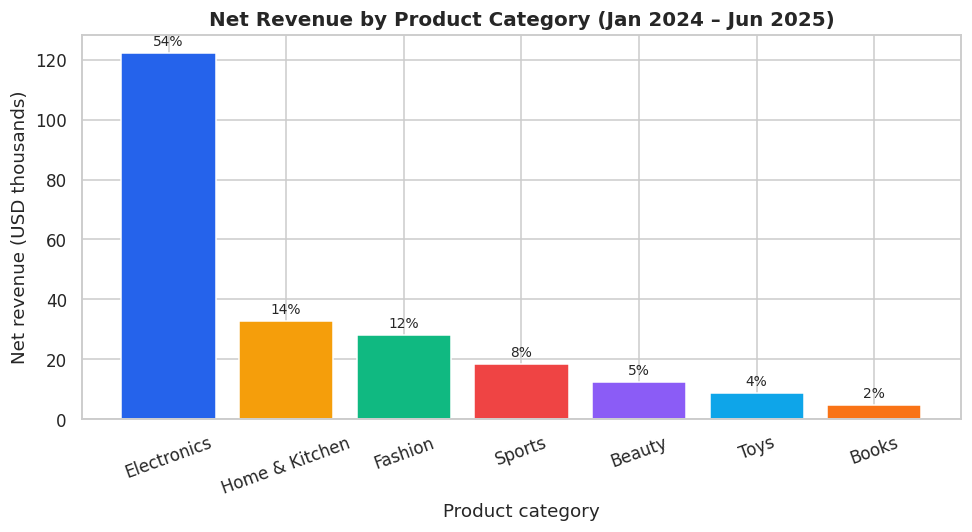

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(cat.index, cat["net_revenue"] / 1000, color=PALETTE[:len(cat)])
ax.bar_label(bars, labels=[f"{v:.0%}" for v in cat["revenue_share"]], padding=3, fontsize=9)
ax.set_title("Net Revenue by Product Category (Jan 2024 – Jun 2025)")
ax.set_xlabel("Product category")
ax.set_ylabel("Net revenue (USD thousands)")
plt.xticks(rotation=20)
save_fig("01_revenue_by_category")

**Interpretation.** The chart makes the revenue concentration from Q1 obvious: Electronics towers over every other category at ≈ $122 k (54 % of revenue), while the remaining six categories share the other 46 %. Home & Kitchen and Fashion are a distant second and third; Books and Toys are almost negligible in revenue terms even though they account for 16 % of orders.

### Chart 2 — Line chart: Monthly orders and revenue trend

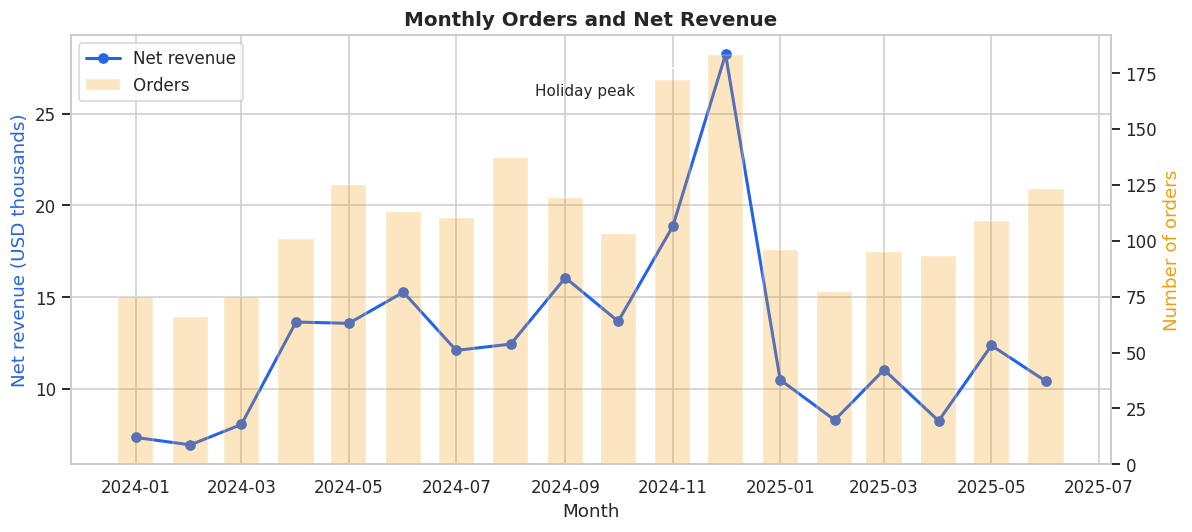

In [38]:
fig, ax1 = plt.subplots(figsize=(11, 5))
x = pd.to_datetime(monthly.index)
ax1.plot(x, monthly["net_revenue"] / 1000, marker="o", color=PALETTE[0], linewidth=2, label="Net revenue")
ax1.set_ylabel("Net revenue (USD thousands)", color=PALETTE[0])
ax1.set_xlabel("Month")
ax2 = ax1.twinx()
ax2.bar(x, monthly["orders"], width=20, alpha=0.25, color=PALETTE[1], label="Orders")
ax2.set_ylabel("Number of orders", color=PALETTE[1])
ax2.grid(False)
ax1.set_title("Monthly Orders and Net Revenue")
ax1.annotate("Holiday peak", xy=(pd.Timestamp("2024-12-01"), 28.2), xytext=(pd.Timestamp("2024-08-15"), 26),
             arrowprops=dict(arrowstyle="->"), fontsize=10)
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")
save_fig("02_monthly_trend")

**Interpretation.** Both orders (bars) and revenue (line) rise through 2024 and spike in November–December, with December 2024 revenue ($28 k) roughly double a normal month. The steep drop in January–February 2025 is the post-holiday trough, after which activity recovers to a level slightly above the equivalent months of 2024. Revenue is more volatile than order count because a handful of high-value Electronics orders can swing a month's total.

### Chart 3 — Histogram: Distribution of order value

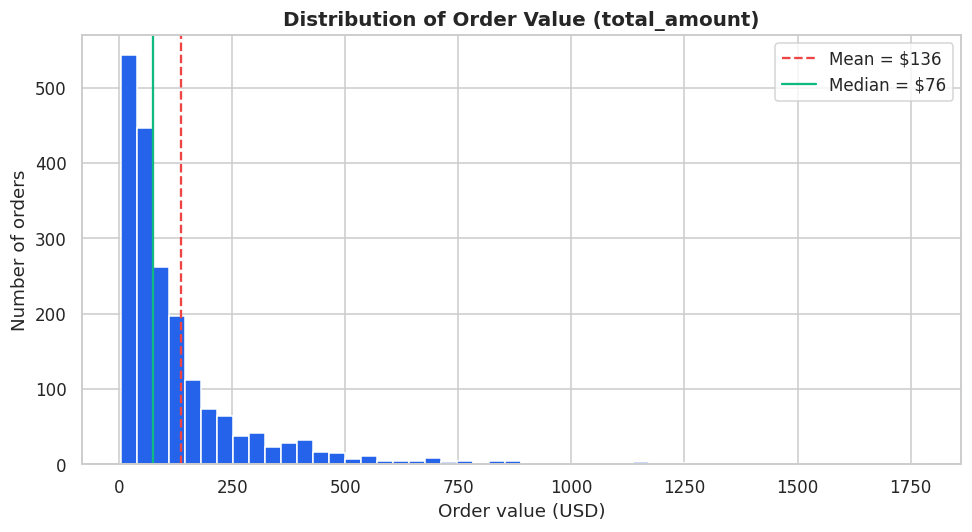

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["total_amount"], bins=50, color=PALETTE[0], edgecolor="white")
ax.axvline(df["total_amount"].mean(), color=PALETTE[3], linestyle="--", label=f"Mean = ${df['total_amount'].mean():.0f}")
ax.axvline(df["total_amount"].median(), color=PALETTE[2], linestyle="-", label=f"Median = ${df['total_amount'].median():.0f}")
ax.set_title("Distribution of Order Value (total_amount)")
ax.set_xlabel("Order value (USD)")
ax.set_ylabel("Number of orders")
ax.legend()
save_fig("03_order_value_histogram")

**Interpretation.** The distribution is strongly right-skewed with a long tail: most orders are under $150, but a small number exceed $500 and reach almost $1,800. The mean ($136) sits well to the right of the median ($76) because of that tail. For reporting "typical" customer spend the median is the safer measure, and any pricing or free-shipping threshold decisions should be based on where the bulk of orders actually sit (the $20–$100 range).

### Chart 4 — Pie chart: Share of orders by customer segment and order status

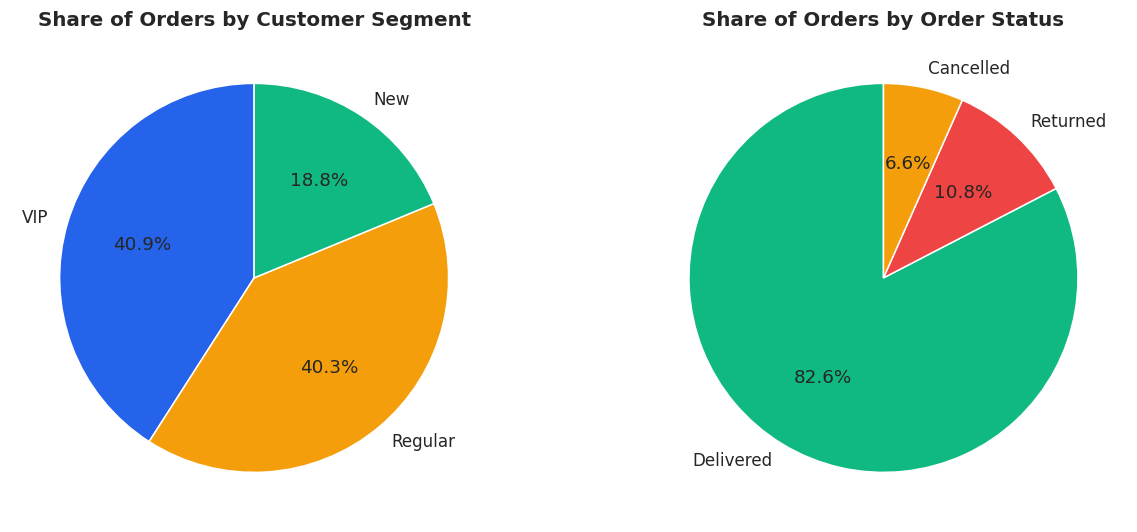

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
seg_counts = df["customer_segment"].value_counts()
axes[0].pie(seg_counts, labels=seg_counts.index, autopct="%1.1f%%", startangle=90,
            colors=PALETTE[:3], wedgeprops=dict(edgecolor="white"))
axes[0].set_title("Share of Orders by Customer Segment")
status_counts = df["order_status"].value_counts()
axes[1].pie(status_counts, labels=status_counts.index, autopct="%1.1f%%", startangle=90,
            colors=[PALETTE[2], PALETTE[3], PALETTE[1]], wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Share of Orders by Order Status")
save_fig("04_pie_segment_status")

**Interpretation.** Although VIPs are the smallest segment by headcount (23 % of customers), they place **41 % of all orders** — the same share as the much larger Regular segment — while New customers, one third of the base, place under 19 % of orders. The right-hand pie shows the revenue leakage highlighted earlier: **17 % of orders end up returned (10.8 %) or cancelled (6.6 %)** and therefore generate no net revenue.

### Chart 5 — Scatter plot: Delivery time vs. review rating

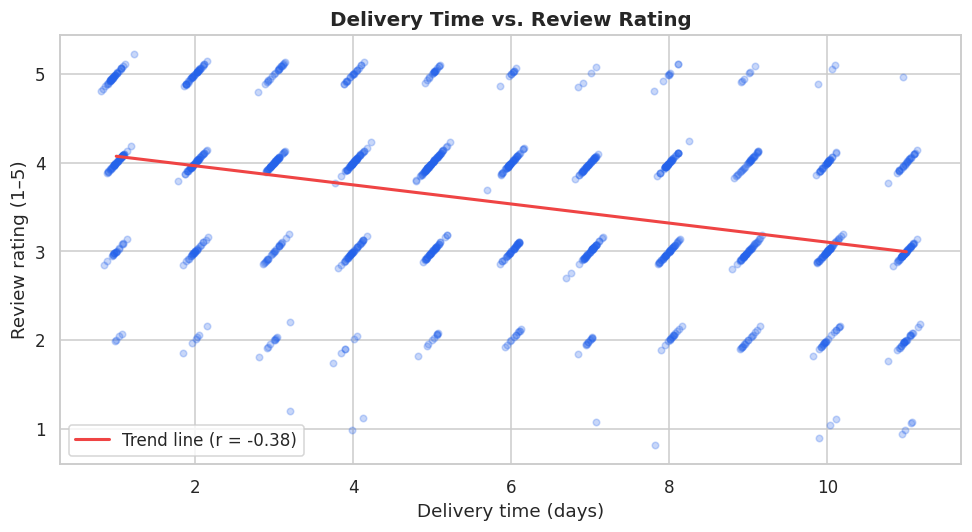

In [41]:
fig, ax = plt.subplots(figsize=(9, 5))
jitter = np.random.default_rng(0).normal(0, 0.08, len(rated))
ax.scatter(rated["delivery_days"] + jitter, rated["review_rating"] + jitter, alpha=0.25, s=18, color=PALETTE[0])
m, b = np.polyfit(rated["delivery_days"], rated["review_rating"], 1)
xs = np.linspace(1, 11, 50)
ax.plot(xs, m * xs + b, color=PALETTE[3], linewidth=2, label=f"Trend line (r = {r:.2f})")
ax.set_title("Delivery Time vs. Review Rating")
ax.set_xlabel("Delivery time (days)")
ax.set_ylabel("Review rating (1–5)")
ax.set_yticks([1, 2, 3, 4, 5])
ax.legend()
save_fig("05_delivery_vs_rating_scatter")

**Interpretation.** Each point is a reviewed order (small random jitter added so overlapping points are visible). The downward-sloping trend line and the visible shift of the point cloud from 4–5 stars at short delivery times to 2–3 stars at long delivery times illustrate the negative correlation (r ≈ −0.38). Every extra day of delivery costs roughly **0.1 star** on average; cutting a 10-day delivery to 3 days would be expected to lift the rating by almost a full point.

### Chart 6 — Box plot: Order value by customer segment

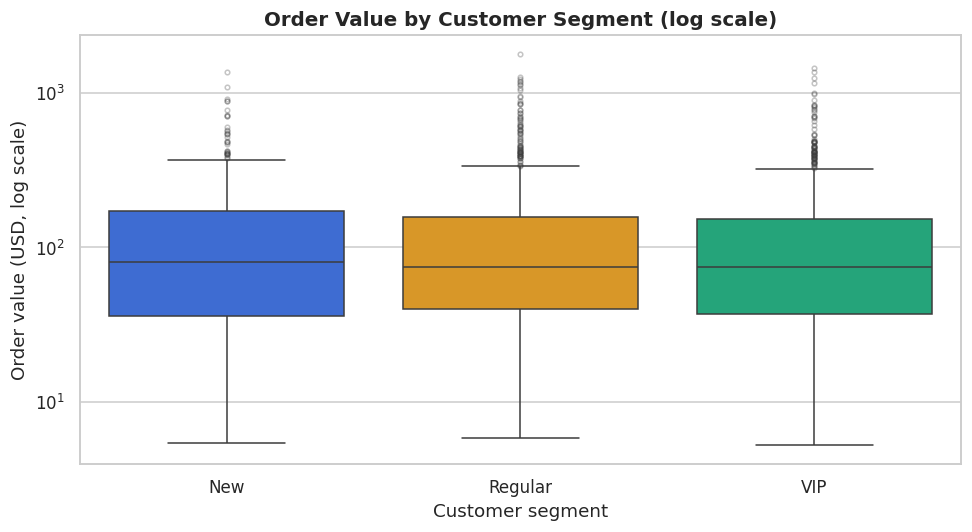

In [42]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="customer_segment", y="total_amount", order=["New", "Regular", "VIP"],
            palette=PALETTE[:3], showfliers=True, flierprops=dict(marker=".", alpha=0.3), ax=ax)
ax.set_yscale("log")
ax.set_title("Order Value by Customer Segment (log scale)")
ax.set_xlabel("Customer segment")
ax.set_ylabel("Order value (USD, log scale)")
save_fig("06_order_value_by_segment_boxplot")

**Interpretation.** The three boxes overlap almost completely: the medians and inter-quartile ranges of order value are very similar for New, Regular and VIP customers (a log scale is used so the long upper tail does not hide the boxes). This visually confirms the t-test result — VIPs do **not** spend more per order; their higher lifetime value comes purely from ordering more often.

### Chart 7 — Grouped bar chart: Return rate and average rating by category

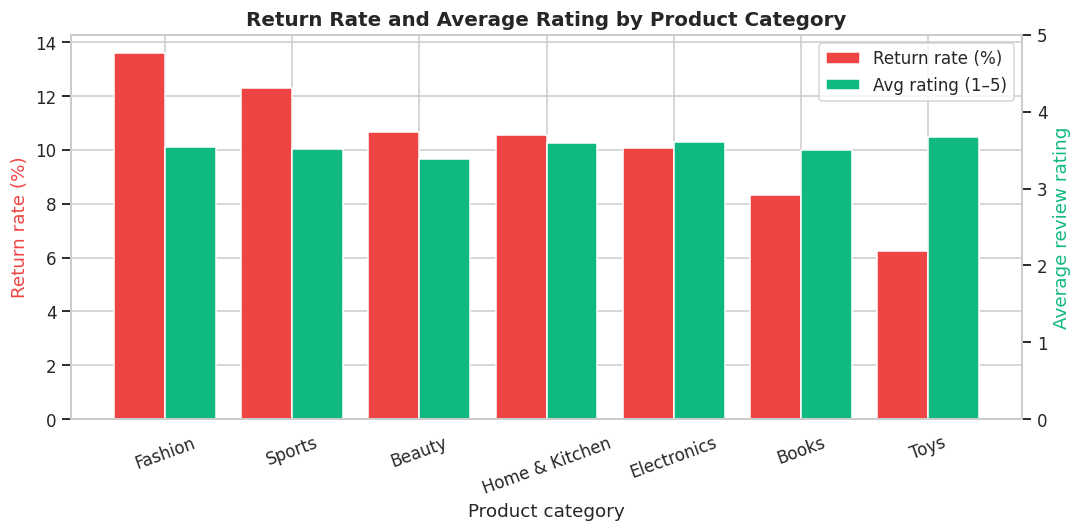

In [43]:
fig, ax1 = plt.subplots(figsize=(10, 5))
order = cat.sort_values("return_rate", ascending=False).index
xpos = np.arange(len(order)); w = 0.4
ax1.bar(xpos - w/2, cat.loc[order, "return_rate"] * 100, width=w, color=PALETTE[3], label="Return rate (%)")
ax1.set_ylabel("Return rate (%)", color=PALETTE[3])
ax1.set_xticks(xpos); ax1.set_xticklabels(order, rotation=20)
ax1.set_xlabel("Product category")
ax2 = ax1.twinx()
ax2.bar(xpos + w/2, cat.loc[order, "avg_rating"], width=w, color=PALETTE[2], label="Avg rating (1–5)")
ax2.set_ylabel("Average review rating", color=PALETTE[2]); ax2.set_ylim(0, 5); ax2.grid(False)
ax1.set_title("Return Rate and Average Rating by Product Category")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")
save_fig("07_return_rate_rating_by_category")

**Interpretation.** Fashion (13.6 %) and Sports (12.3 %) are returned most often, roughly twice the rate of Toys (6.2 %). Average ratings are fairly flat (3.4–3.7) across categories, with Beauty lowest and Toys highest, so satisfaction differences between categories are smaller than the differences in return behaviour. Fashion's high return rate is the clearest operational target because it is also the third-largest revenue category.

### Chart 8 — Heatmap: Correlation matrix of numeric variables

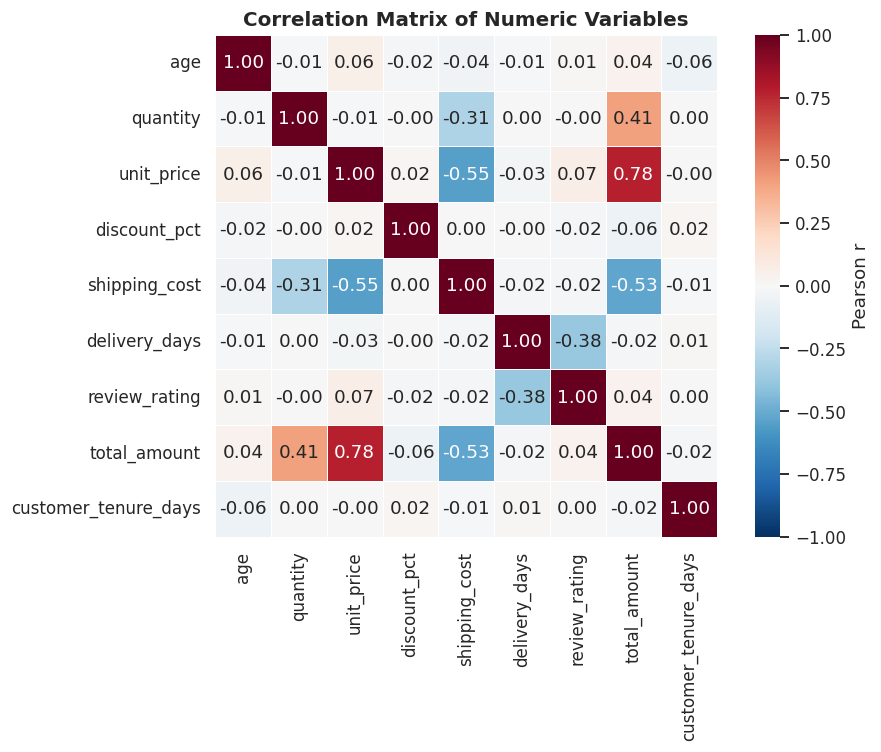

In [44]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation Matrix of Numeric Variables")
save_fig("08_correlation_heatmap")

**Interpretation.** Warm cells mark positive and cool cells negative correlations. The strongest relationships are mechanical (`total_amount` with `unit_price` 0.78 and `quantity` 0.41). The only notable behavioural correlation is the blue cell for `delivery_days` × `review_rating` (−0.38). Everything else is close to zero — age, tenure and discount are not meaningfully related to spending or satisfaction, so demographic targeting by age alone is unlikely to raise order value.

### Chart 9 — Stacked bar: Payment method mix by age group

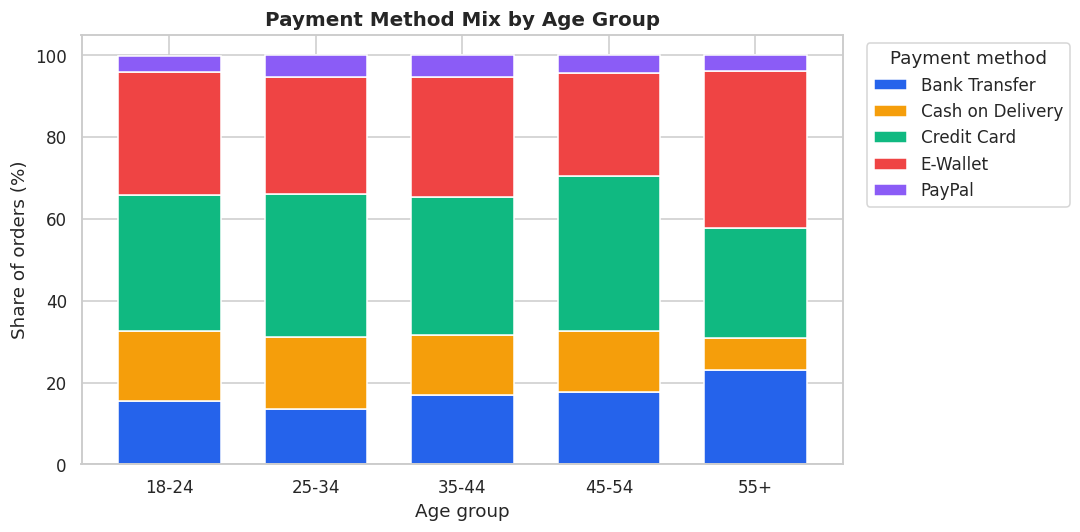

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
(ct_pay * 100).plot(kind="bar", stacked=True, ax=ax, color=PALETTE[:5], width=0.7, edgecolor="white")
ax.set_title("Payment Method Mix by Age Group")
ax.set_xlabel("Age group")
ax.set_ylabel("Share of orders (%)")
ax.legend(title="Payment method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
save_fig("09_payment_mix_by_age")

**Interpretation.** Credit Card and E-Wallet together cover 60–65 % of orders in every age group, but the mix shifts with age: Cash on Delivery shrinks from 17 % among 18–24-year-olds to 8 % among the 55+ group, whose members lean instead on E-Wallet and Bank Transfer. PayPal is marginal (≈ 5 %) everywhere. Offering (and promoting) E-Wallet payment is the single option that satisfies the widest range of customers.

---
## 13. Key Findings & Recommendations

### 13.1 Key findings (evidence-based)

| # | Finding | Evidence |
|---|---------|----------|
| **F1** | **Revenue is highly concentrated in Electronics.** One category produces over half of all revenue; three categories produce ≈ 80 %. | Electronics = 54 % of net revenue from 24 % of orders; AOV $304 vs $34–$121 elsewhere (Section 10.2, Chart 1). |
| **F2** | **VIP customers drive value through frequency, not basket size.** | VIPs = 23 % of customers, 40 % of revenue, 4.8 orders each vs 1.6 for New; AOV difference VIP vs New not significant (p > 0.05) (Sections 10.3, 11, Chart 6). |
| **F3** | **Slow delivery measurably hurts satisfaction.** | Rating falls from 3.96 (1–3 days) to 3.02 (10+ days); Pearson r = −0.38, p < 0.001; ANOVA significant (Sections 10.6, 11, Chart 5). |
| **F4** | **Almost one in five orders produces no revenue.** | 10.8 % returned + 6.6 % cancelled = 17.4 % of orders; Fashion has the highest return rate (13.6 %) (Sections 10.1, 10.2, Charts 4 & 7). |
| **F5** | **Strong year-end seasonality with a post-holiday slump.** | December 2024 = 183 orders / $28 k (≈ 2.4× Q1 monthly average); January 2025 revenue −63 % MoM (Section 10.4, Chart 2). |
| **F6** | **Retention is good but a large share of customers has gone quiet.** | 67 % repeat-purchase rate and top 20 % of customers = 57 % of revenue, yet 45 % of customers have not ordered in 180+ days; New customers only 40 % repeat (Section 10.7). |
| **F7** | **Referral brings the least valuable customers; Email the most.** | Revenue per customer: Email $325, Social $333, Referral $237 (29 % below average) (Section 10.5). |

### 13.2 Recommendations (actionable)

| # | Recommendation | Linked finding | Expected impact / how to measure |
|---|----------------|----------------|----------------------------------|
| **R1** | **Set a delivery-time SLA of ≤ 5 days** for the top markets (Cambodia, Thailand, Vietnam) — renegotiate courier contracts or add a regional fulfilment hub — and show estimated delivery dates at checkout. | F3 | Each day saved ≈ +0.1 star; target average rating from 3.55 to ≥ 3.9 within two quarters. |
| **R2** | **Launch a second-purchase programme for New customers**: an automated email/e-wallet voucher 14 days after the first delivered order, plus a win-back campaign for the 45 % of customers inactive > 180 days. | F2, F6 | Raise New-customer repeat rate from 40 % toward the Regular level (70 %); track repeat rate and 180-day recency monthly. |
| **R3** | **Reduce Fashion and Sports returns**: add size guides, fit-based reviews and more product photos; analyse return reasons. | F4 | Bring Fashion returns from 13.6 % to the category average (~10 %), recovering ≈ $1 k+ per 1,000 orders in refunded revenue and shipping. |
| **R4** | **Diversify revenue away from Electronics** by cross-selling Home & Kitchen / Sports bundles to Electronics buyers, and by promoting higher-margin Beauty products to the Cambodia and Indonesia markets where AOV is highest. | F1 | Reduce Electronics share below 50 % while growing total revenue; monitor category revenue share quarterly. |
| **R5** | **Plan inventory and marketing around the seasonal curve**: build Electronics stock and ad budget for Nov–Dec, and run a January "new-year" promotion to soften the post-holiday drop. | F5 | Reduce the Jan/Feb revenue trough (currently −63 % MoM) to ≤ −40 %. |
| **R6** | **Rebalance acquisition spend**: shift part of the Referral budget to Email and Social Media, and redesign referral rewards so they are paid only after the referred customer's second order. | F7 | Raise revenue per acquired customer from Referral above $300. |
| **R7** | **Protect VIP margin**: cap VIP discounts at ≈ 10 % and replace extra discounts with non-price perks (free express shipping — which also supports R1). | F2 | Maintain VIP order frequency while improving contribution margin. |

### 13.3 Limitations & next steps

* The dataset is synthetic (generated to mimic realistic patterns) and contains no cost or margin data, so recommendations are framed around revenue, not profit.
* Return/category differences were not statistically significant at n ≈ 2,000; a larger sample or return-reason data would strengthen R3.
* Next steps: build a churn-prediction model on the customer table, add SKU-level and marketing-spend data, and automate this notebook as a monthly report.